## Landsat and Sentinel Surface Reflectance Products


In [1]:
import sys
import datacube
import matplotlib.pyplot as plt

sys.path.insert(1, '.../Tools/')
from datacube.utils import masking
from dea_tools.datahandling import mostcommon_crs, load_ard
from dea_tools.plotting import rgb
from odc.ui import with_ui_cbk
from dea_tools.dask import create_local_dask_cluster

In [2]:
dc = datacube.Datacube(app="jenna_product_exploration")

client = create_local_dask_cluster(return_client=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35307,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:34689,Total threads: 2
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/34073/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:43749,


2025-01-13 21:48:12,546 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-ec8421dfd6614e07865a8a1288696077' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7ff53e722440>, (Dataset <id=ec8421df-d661-4e07-865a-8a1288696077 product=ga_s2am_ard_3 location=s3://dea-public-data/baseline/ga_s2am_ard_3/56/JNP/2018/01/16/20180117T011158/ga_s2am_ard_3-2-1_56JNP_2018-01-16_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7ff53e722440>, (Dataset <id=ec8421df-d661-4e07-865a-8a1288696077 product=ga_s2am_ard_3 location=s3://dea-public-data/baseline/ga_s2a

In [3]:
dc_products = dc.list_products()
dc_products.loc[['ga_ls5t_ard_3', 'ga_ls7e_ard_3', 'ga_ls8c_ard_3', 'ga_ls9c_ard_3', 'ga_s2am_ard_3', 'ga_s2bm_ard_3']]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_ls5t_ard_3,ga_ls5t_ard_3,Geoscience Australia Landsat 5 Thematic Mapper...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls7e_ard_3,ga_ls7e_ard_3,Geoscience Australia Landsat 7 Enhanced Themat...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls8c_ard_3,ga_ls8c_ard_3,Geoscience Australia Landsat 8 Operational Lan...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls9c_ard_3,ga_ls9c_ard_3,Geoscience Australia Landsat 9 Operational Lan...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_s2am_ard_3,ga_s2am_ard_3,Geoscience Australia Sentinel 2A MSI Analysis ...,CC-BY-4.0,EPSG:3577,"(-10, 10)"
ga_s2bm_ard_3,ga_s2bm_ard_3,Geoscience Australia Sentinel 2B MSI Analysis ...,CC-BY-4.0,EPSG:3577,"(-10, 10)"


In [4]:
dc_measurements = dc.list_measurements()
dc_measurements.loc[['ga_ls8c_ard_3']]

name    dtype  \
product       measurement                                                       
ga_s2am_ard_3 nbart_coastal_aerosol            nbart_coastal_aerosol    int16   
              nbart_blue                                  nbart_blue    int16   
              nbart_green                                nbart_green    int16   
              nbart_red                                    nbart_red    int16   
              nbart_red_edge_1                      nbart_red_edge_1    int16   
              nbart_red_edge_2                      nbart_red_edge_2    int16   
              nbart_red_edge_3                      nbart_red_edge_3    int16   
              nbart_nir_1                                nbart_nir_1    int16   
              nbart_nir_2                                nbart_nir_2    int16   
              nbart_swir_2                              nbart_swir_2    int16   
              nbart_swir_3                              nbart_swir_3    int16   
              oa_fmask                                      oa_fmask    uint8   
              oa_nbart_contiguity                oa_nbart_contiguity    uint8   
              oa_azimuthal_exiting              oa_azimuthal_exiting  float32   
              oa_azimuthal_incident            oa_azimuthal_incident  float32   
              oa_combined_terrain_shadow  oa_combined_terrain_shadow    uint8   
              oa_exiting_angle                      oa_exiting_angle  float32   
              oa_incident_angle                    oa_incident_angle  float32   
              oa_relative_azimuth                oa_relative_azimuth  float32   
              oa_relative_slope                    oa_relative_slope  float32   
              oa_satellite_azimuth              oa_satellite_azimuth  float32   
              oa_satellite_view                    oa_satellite_view  float32   
              oa_solar_azimuth                      oa_solar_azimuth  float32   
              oa_solar_zenith                        oa_solar_zenith  float32   
              oa_time_delta                            oa_time_delta  float32   
              oa_s2cloudless_mask                oa_s2cloudless_mask    uint8   
              oa_s2cloudless_prob                oa_s2cloudless_prob  float64   

                                         units nodata  \
product       measurement                               
ga_s2am_ard_3 nbart_coastal_aerosol          1   -999   
              nbart_blue                     1   -999   
              nbart_green                    1   -999   
              nbart_red                      1   -999   
              nbart_red_edge_1               1   -999   
              nbart_red_edge_2               1   -999   
              nbart_red_edge_3               1   -999   
              nbart_nir_1                    1   -999   
              nbart_nir_2                    1   -999   
              nbart_swir_2                   1   -999   
              nbart_swir_3                   1   -999   
              oa_fmask                       1      0   
              oa_nbart_contiguity            1    255   
              oa_azimuthal_exiting           1    NaN   
              oa_azimuthal_incident          1    NaN   
              oa_combined_terrain_shadow     1    255   
              oa_exiting_angle               1    NaN   
              oa_incident_angle              1    NaN   
              oa_relative_azimuth            1    NaN   
              oa_relative_slope              1    NaN   
              oa_satellite_azimuth           1    NaN   
              oa_satellite_view              1    NaN   
              oa_solar_azimuth               1    NaN   
              oa_solar_zenith                1    NaN   
              oa_time_delta                  1    NaN   
              oa_s2cloudless_mask            1      0   
              oa_s2cloudless_prob            1    NaN   

                                                            

In [5]:
s2_query = {
    "x": (153.45, 153.47),
    "y": (-28.0, -28.02),
    "time": ("2018-01-01", "2018-01-31"),
    "output_crs": "EPSG:3577",
    "resolution": (-10, 10),
    "group_by": "solar_day"
}

In [6]:
ls8_ds = dc.load(product='ga_ls8c_ard_3',
                measurements = ['nbart_red', 'nbart_green', 'nbart_blue', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'oa_fmask'],
                x = (149.05, 149.17),
                y = (-35.25, -35.32),
                time = '2021-06-27',
                group_by = 'solar_day')

In [7]:
s2_ds = dc.load(product = "ga_s2am_ard_3",
               progress_cbk = with_ui_cbk(),
               **s2_query)

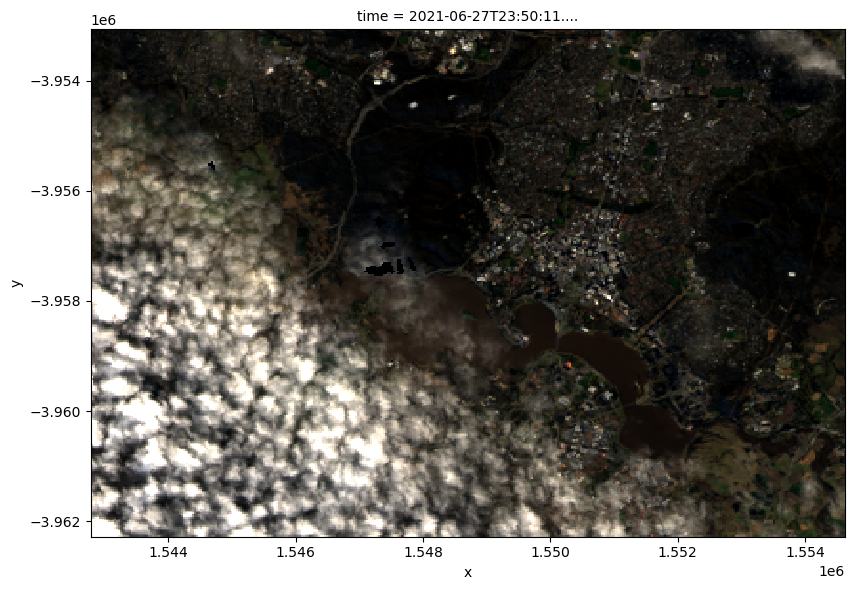

In [8]:
rgb(ls8_ds, col='time') # we only have a single epoch here

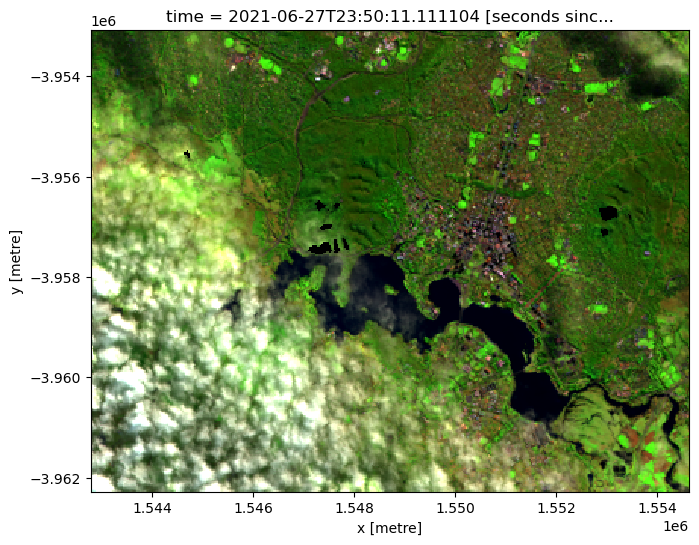

In [9]:
rgb(ls8_ds, bands = ['nbart_swir_1', 'nbart_nir', 'nbart_green'])

In [10]:
# cloud masking using FMask

masking.describe_variable_flags(ls8_ds.oa_fmask)['values'][0]

/tmp/ipykernel_223/665251158.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  masking.describe_variable_flags(ls8_ds.oa_fmask)['values'][0]


{'0': 'nodata',
 '1': 'valid',
 '2': 'cloud',
 '3': 'shadow',
 '4': 'snow',
 '5': 'water'}

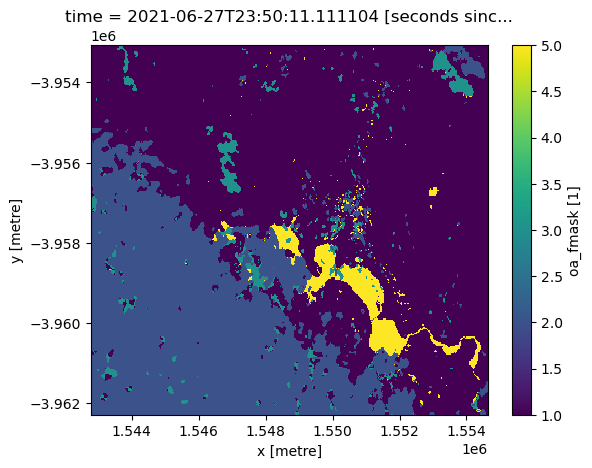

In [11]:
ls8_ds.oa_fmask.plot() #single band, so we can just use plot instead of rgb()

**Note: Fmask's "water" mask should typically not be relied to accurately analyse water using satellite data. Instead, consider loading data from the DEA Water Observations product instead.**

In [12]:
ls8_cloud_free_mask = (masking.make_mask(ls8_ds.oa_fmask, fmask = 'valid') |
                     masking.make_mask(ls8_ds.oa_fmask, fmask = 'water') |
                     masking.make_mask(ls8_ds.oa_fmask, fmask = 'snow'))

ls8_masked = ls8_ds.where(ls8_cloud_free_mask)

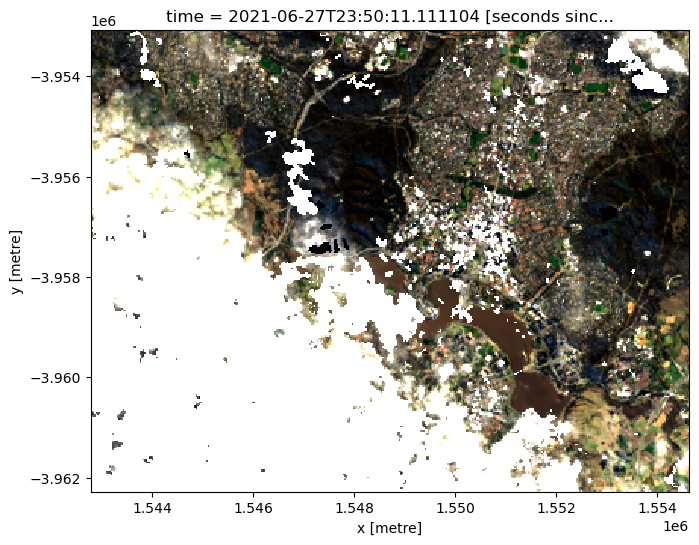

In [13]:
rgb(ls8_masked)

Finding datasets
    ga_ls8c_ard_3
Applying morphological filters to pixel quality mask: [('dilation', 3)]
Applying fmask pixel quality/cloud mask
Loading 1 time steps


/env/lib/python3.10/site-packages/dea_tools/datahandling.py:484: UserWarning: As of `dea_tools` v0.3.0, pixel quality masks are inverted before being passed to `mask_filters` (i.e. so that good quality/clear pixels are False and poor quality pixels/clouds are True). This means that 'dilation' will now expand cloudy pixels, rather than shrink them as in previous versions.
  warnings.warn(


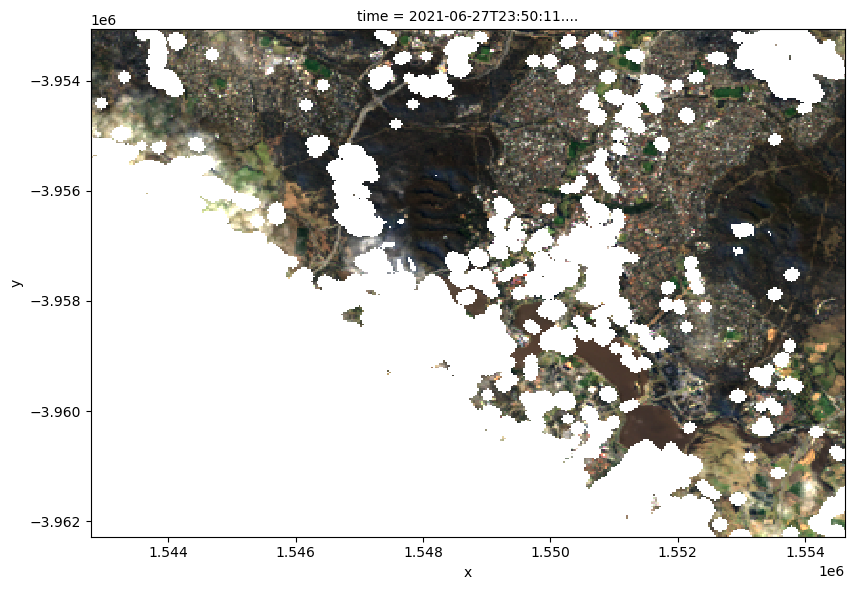

In [14]:
# loading AND masking by using the load_ard function
# you can also add mask filters like dilation to include buffers around masked pixels, also adding these to the mask.

ard_ds = load_ard(dc=dc,
                 products = ['ga_ls8c_ard_3'],
                 measurements = ['nbart_red', 'nbart_green', 'nbart_blue'],
                 x=(149.05, 149.17),
                 y=(-35.25, -35.32),
                 time='2021-06-27',
                 group_by = 'solar_day',
                 mask_filters = [('dilation', 3)])

rgb(ard_ds, col='time', vmin=0, vmax=2000)

## landsat SR advanced topics and caveats
### native loading

Reprojecting these data into a single projection system like Australian Albers (`EPSG:3577`) will force datacube to resample the data to fit this new spatial grid. This can lead to artefacts in the resulting imagery that can affect its usefulness for precise applications (e.g. using Landsat to accurately map the boundary between land and water using sub-pixel techniques).

Loading Landsat data in its native projection and resolution can be helpful here. 

Figure out which UTM zone the scenes are in and use that to load data in that CRS. DEA tool `mostcommon_crs` helps you do that.

### Filtering by metadata

You can also use the metadata for the surface reflectance data as a filter when using `dc.load()`. e.g. `cloud_cover`

**Some useful metadata options:**

`gqa_iterative_mean_xy`: An estimate of how accurately a satellite scene is georeferenced, calculated by comparing hundreds of candidate Ground Control Points, then discarding outliers to obtain a more robust estimate. 

#### Values are in pixel units based on a 25 metre resolution reference image (i.e. 0.2 = 5 metres)

This parameter can be used to ensure that we only load data that is closely aligned spatially through time. 


In [15]:
query = {
    'x': (149.05, 149.17),
    'y': (-35.25, -35.32),
    'time': '2021-06-27'
}

native_crs = mostcommon_crs(dc, product = 'ga_ls8c_ard_3', query=query)
native_crs

'epsg:32655'

In [16]:
ls8_native = dc.load(
    product = 'ga_ls8c_ard_3',
    measurements = ['nbart_red', 'nbart_green', 'nbart_blue'],
    output_crs = native_crs,
    resolution = (-30,30),
    align = (15,15),
    gqa_iterative_mean_xy = (0, 0.5), #geometric accuracy of 12.5 aka 50% of the 25m reference pixel
    group_by = 'solar_day',
    **query
)

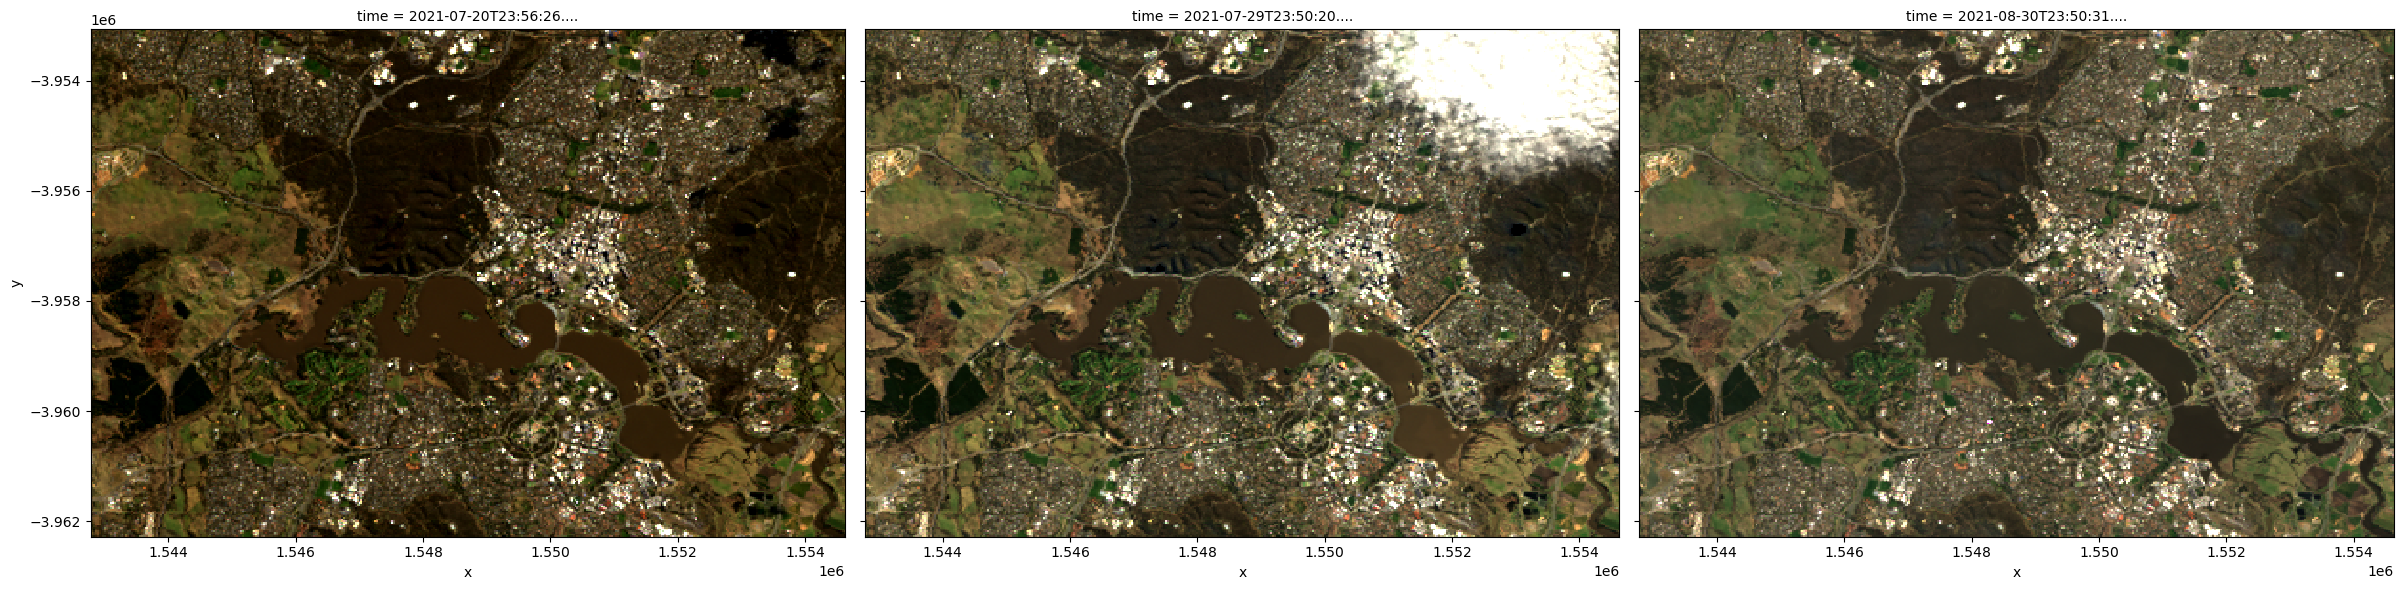

In [18]:
ls8_nocloud = dc.load(
    product = 'ga_ls8c_ard_3',
    measurements = ['nbart_red', 'nbart_green', 'nbart_blue'],
    x = (149.05, 149.17),
    y = (-35.25, -35.32),
    time=('2021-06', '2021-09'),
    cloud_cover = (0, 5),
    group_by = 'solar_day',
)

rgb(ls8_nocloud, col='time')

## Sentinel SR


In [19]:
dc_measurements.loc[['ga_s2am_ard_3']]

name    dtype  \
product       measurement                                                       
ga_s2am_ard_3 nbart_coastal_aerosol            nbart_coastal_aerosol    int16   
              nbart_blue                                  nbart_blue    int16   
              nbart_green                                nbart_green    int16   
              nbart_red                                    nbart_red    int16   
              nbart_red_edge_1                      nbart_red_edge_1    int16   
              nbart_red_edge_2                      nbart_red_edge_2    int16   
              nbart_red_edge_3                      nbart_red_edge_3    int16   
              nbart_nir_1                                nbart_nir_1    int16   
              nbart_nir_2                                nbart_nir_2    int16   
              nbart_swir_2                              nbart_swir_2    int16   
              nbart_swir_3                              nbart_swir_3    int16   
              oa_fmask                                      oa_fmask    uint8   
              oa_nbart_contiguity                oa_nbart_contiguity    uint8   
              oa_azimuthal_exiting              oa_azimuthal_exiting  float32   
              oa_azimuthal_incident            oa_azimuthal_incident  float32   
              oa_combined_terrain_shadow  oa_combined_terrain_shadow    uint8   
              oa_exiting_angle                      oa_exiting_angle  float32   
              oa_incident_angle                    oa_incident_angle  float32   
              oa_relative_azimuth                oa_relative_azimuth  float32   
              oa_relative_slope                    oa_relative_slope  float32   
              oa_satellite_azimuth              oa_satellite_azimuth  float32   
              oa_satellite_view                    oa_satellite_view  float32   
              oa_solar_azimuth                      oa_solar_azimuth  float32   
              oa_solar_zenith                        oa_solar_zenith  float32   
              oa_time_delta                            oa_time_delta  float32   
              oa_s2cloudless_mask                oa_s2cloudless_mask    uint8   
              oa_s2cloudless_prob                oa_s2cloudless_prob  float64   

                                         units nodata  \
product       measurement                               
ga_s2am_ard_3 nbart_coastal_aerosol          1   -999   
              nbart_blue                     1   -999   
              nbart_green                    1   -999   
              nbart_red                      1   -999   
              nbart_red_edge_1               1   -999   
              nbart_red_edge_2               1   -999   
              nbart_red_edge_3               1   -999   
              nbart_nir_1                    1   -999   
              nbart_nir_2                    1   -999   
              nbart_swir_2                   1   -999   
              nbart_swir_3                   1   -999   
              oa_fmask                       1      0   
              oa_nbart_contiguity            1    255   
              oa_azimuthal_exiting           1    NaN   
              oa_azimuthal_incident          1    NaN   
              oa_combined_terrain_shadow     1    255   
              oa_exiting_angle               1    NaN   
              oa_incident_angle              1    NaN   
              oa_relative_azimuth            1    NaN   
              oa_relative_slope              1    NaN   
              oa_satellite_azimuth           1    NaN   
              oa_satellite_view              1    NaN   
              oa_solar_azimuth               1    NaN   
              oa_solar_zenith                1    NaN   
              oa_time_delta                  1    NaN   
              oa_s2cloudless_mask            1      0   
              oa_s2cloudless_prob            1    NaN   

                                                            

In [24]:
query = {
    'x': (153.45, 153.47),
    'y': (-28.90, -28.92),
    'time': ('2018-01-01', '2018-01-31'),
    'output_crs': 'EPSG:3577',
    'resolution': (-10, 10),
    'group_by': 'solar_day'
}

bands = ['nbart_blue', 'nbart_green', 'nbart_red', 'oa_s2cloudless_mask', 'oa_s2cloudless_prob']

dataset_maturity = 'final'

In [34]:
# for a single product, it is product = product_name
s2_ds = dc.load(product = 'ga_s2am_ard_3', 
                measurements = bands,
                progress_cbk = with_ui_cbk(),
                dataset_maturity = dataset_maturity,
                dask_chunks = {'time': 1, 'x': 2048, 'y': 2048},
               **query)

s2_ds

<xarray.Dataset> Size: 3MB
Dimensions:              (time: 3, y: 255, x: 228)
Coordinates:
  * time                 (time) datetime64[ns] 24B 2018-01-06T23:52:37.461000...
  * y                    (y) float64 2kB -3.313e+06 -3.313e+06 ... -3.316e+06
  * x                    (x) float64 2kB 2.057e+06 2.057e+06 ... 2.059e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) int16 349kB dask.array<chunksize=(1, 255, 228), meta=np.ndarray>
    nbart_green          (time, y, x) int16 349kB dask.array<chunksize=(1, 255, 228), meta=np.ndarray>
    nbart_red            (time, y, x) int16 349kB dask.array<chunksize=(1, 255, 228), meta=np.ndarray>
    oa_s2cloudless_mask  (time, y, x) uint8 174kB dask.array<chunksize=(1, 255, 228), meta=np.ndarray>
    oa_s2cloudless_prob  (time, y, x) float64 1MB dask.array<chunksize=(1, 255, 228), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


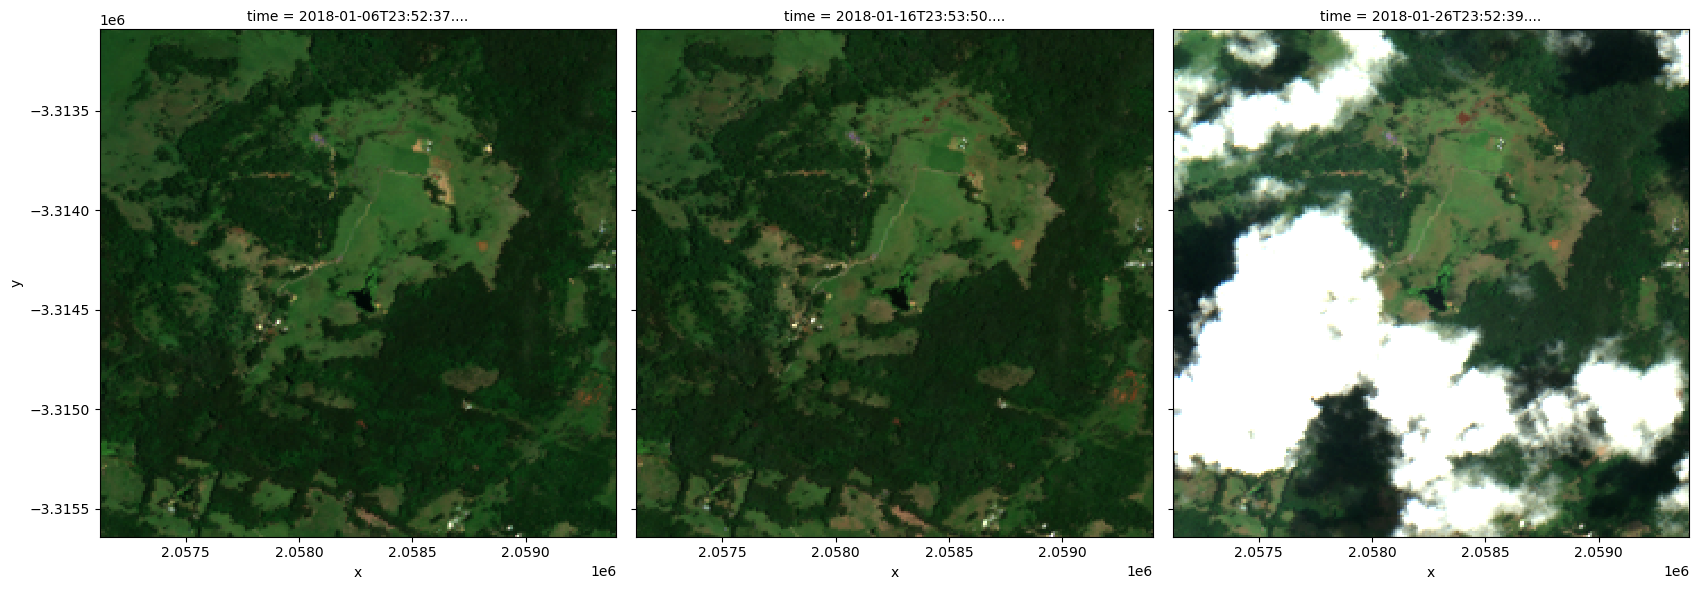

In [30]:
rgb(s2_ds, col='time', vmin=0, vmax=2000)

For loading multiple products you need to use a different function.

`load_ard()`, not `load()`

then call the datacube with `dc=dc`

for multiple, call `products` (instead of `product`) and then pass a list e.g. `products = [product_1, product_2]`



Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Applying fmask pixel quality/cloud mask
Loading 7 time steps


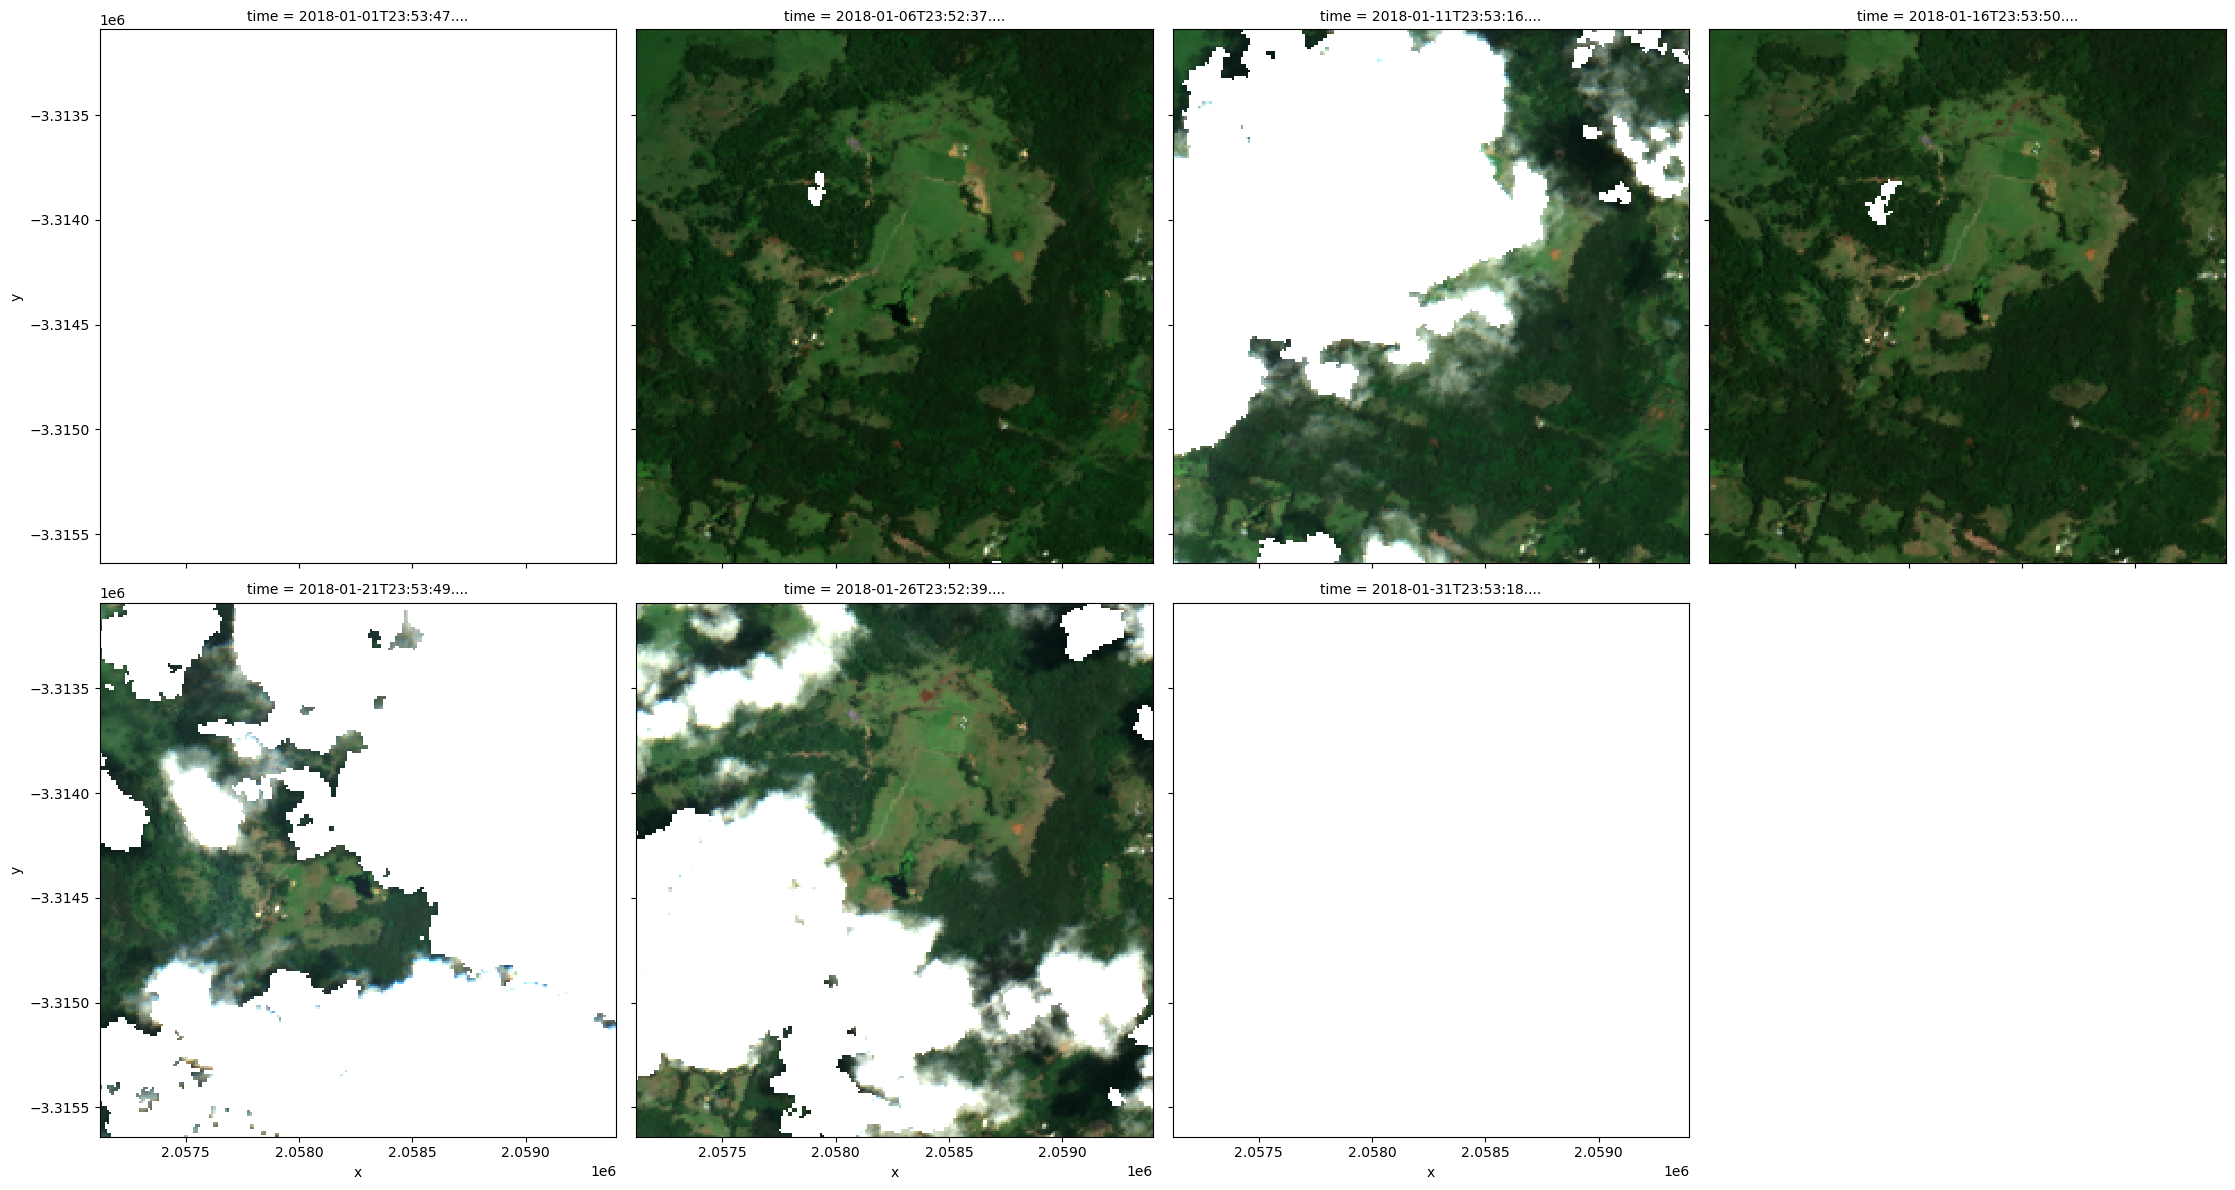

In [37]:
s2_ds_ard = load_ard(
    dc=dc,
    products = ['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
    measurements=bands,
    **query)

rgb(s2_ds_ard, col='time', vmin=0, vmax=2000)

### Sentinel cloud masking

The S2 data comes with two cloud masks, `Fmask` and `s2cloudless`.

In short, `Fmask` masks cloud pixels based on their physical characteristics such as brightness, temperature and elevation. 

**This is a problem for Sentinel-2 as it does not have a thermal infrared sensor, which can lead to false positive cloud classifications over bright features like urban areas or coastlines.** 

`s2cloudless` is a single-scene, pixel-based, ML-based cloud detector trained specifically on Sentinel-2 data, so may produce more accurate cloud classifications on Sentinel-2 data.

#### But wait!

In addition to clouds, `Fmask` also classifies cloud shadows, snow and water whereas s2cloudless only does clouds.


#### DEA's oa_s2cloudless_mask layer is calculated using the following steps:

- Calculating a moving average of cloud probabilities over a 4 * 60 m pixel window to reduce narrow/small false positives (i.e. ~240 m)
- Identifying pixels with a cloud probability of greater than 0.4 (i.e. 40% likelihood of being a cloud)
- Dilating these cloud pixels by 2 pixels to conservatively mask out thin cloud edges (i.e. ~120 m)


#### Customising the `s2cloudless` mask

- can also do things like change the cloud probability threshold (the default being 40%).
- Example: `dst2probmasked = ds_t2.where(ds_t2.oa_s2cloudless_prob < 0.9)`
- sometimes it's hard to see in the plots where the mask is because the default colour is white. You can change this by setting the `NaN` regions to 0 instead.


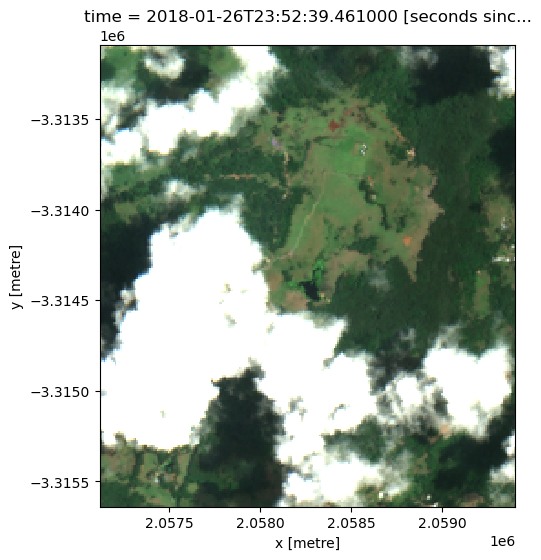

In [39]:
ds_ts = s2_ds.isel(time=2)

rgb(ds_ts, vmin=0, vmax=2000)

In [40]:
ds_ts.oa_s2cloudless_mask.flags_definition

{'s2cloudless_mask': {'bits': [0, 1, 2],
  'values': {'0': 'nodata', '1': 'valid', '2': 'cloud'},
  'description': 's2cloudless mask'}}

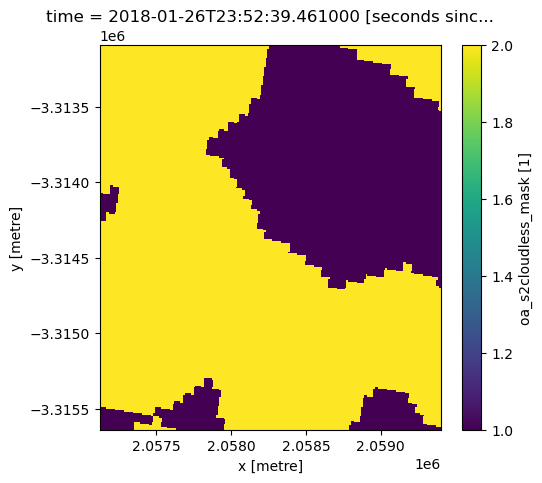

In [41]:
ds_ts.oa_s2cloudless_mask.plot(aspect = 1.1, size=5)

Identify pixels that are "valid" (i.e. containing no cloud). Remember 0 = not valid, 1 = no cloud and 2 = cloud, so alternatively you could create the same mask using `ds_t2.oa_s2cloudless_mask == 1`

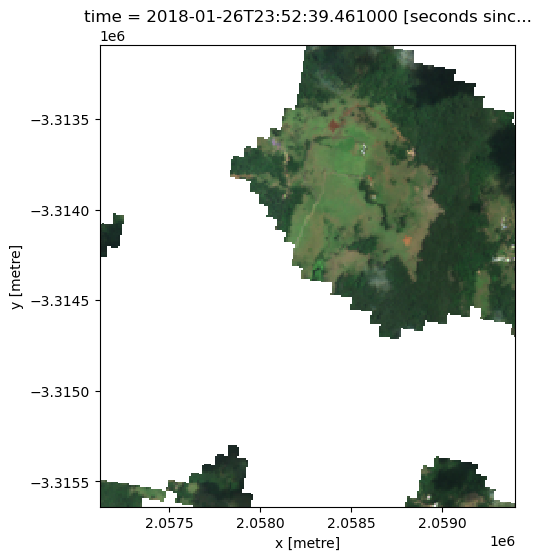

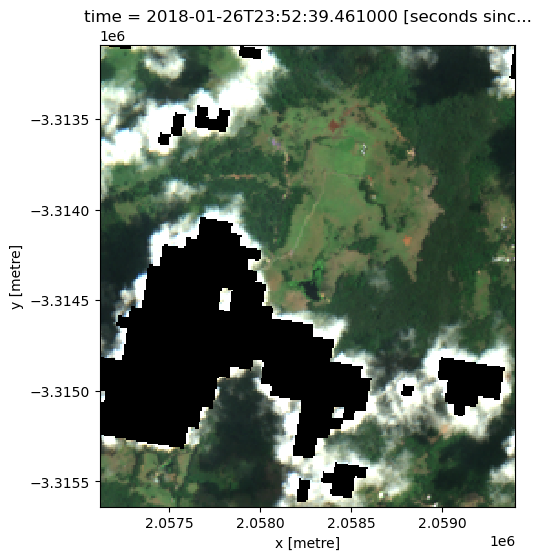

In [47]:
cloud_free_mask = masking.make_mask(ds_ts.oa_s2cloudless_mask,
                                   s2cloudless_mask='valid')

dst2masked = ds_ts.where(cloud_free_mask)

dst2probmasked = ds_ts.where(ds_ts.oa_s2cloudless_prob < 0.9)
dst2probmaskedzero = dst2probmasked.where(~dst2probmasked.isnull(), 0) # force the masked pixels to 0 instead of null so we can see them better in the plot

rgb(dst2masked, vmin=0, vmax=2000)
rgb(dst2probmaskedzero, vmin=0, vmax=2000)

### Using `load_ard` instead of load and other stuff

`load_ard` has a `cloud_mask` option where you can select a mask. You then give the flag `mask_pixel_quality=True` to apply the mask.

#### Dropping cloudy granules

If a granule is mostly cloud, masking might be pointless as you'll only have a handful of pixels. In this case, it makes more sense to drop the granule. You can drop granules based on the cloud mask data.

This code will generate a new dataset where True is everywhere with cloud and False is everything else, and then make a spatial mean to end up with a cloud percentage for each time index.

`percent_cloud = (ds.oa_s2cloudless_mask == 2).mean(dim=['x', 'y'])`

`ds_noncloudy = ds.sel(time=percent_cloud < 0.25`

#### `min_gooddata`

This gets used when loading data with `load_ard`. **IT works the opposite way to the above example** in that it counts the GOOD quality pixels (ie non cloudy) in each image. So, to keep images with <25% cloud cover you would specify `min_gooddata=0.75`

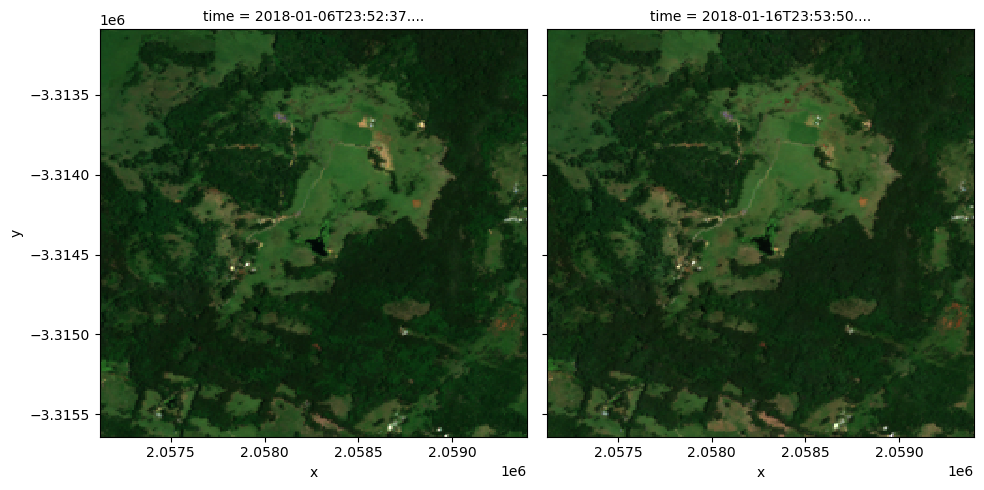

In [51]:
percent_cloud = (s2_ds.oa_s2cloudless_mask == 2).mean(dim=['x', 'y'])

ds_noncloudy = s2_ds.sel(time=percent_cloud < 0.25)

rgb(ds_noncloudy, col='time', vmin=0, vmax=2000, size=5)

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 2 out of 7 time steps with at least 75.0% good quality pixels
Loading 2 time steps


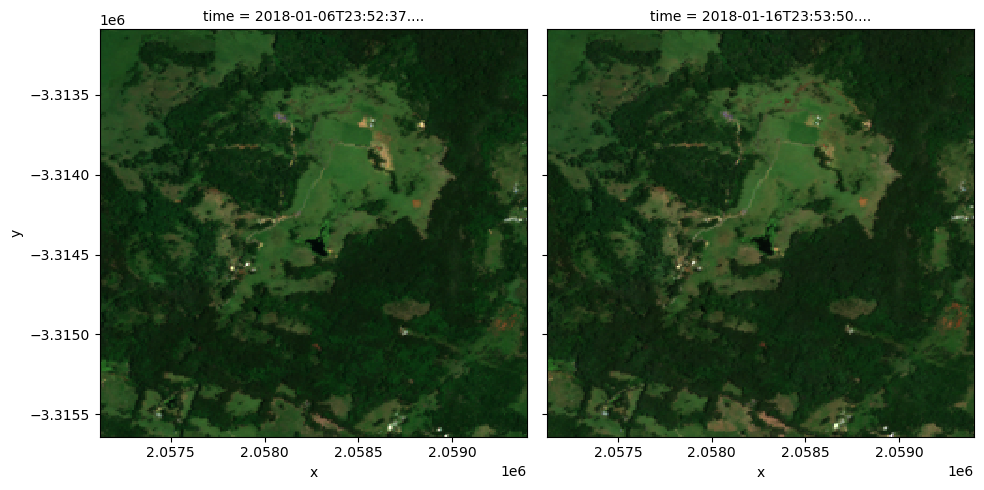

In [52]:
# dropping granules/scene while loading using load_ard()

ds_noncloudy = load_ard(
    dc=dc,
    products = ['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
    measurements = bands,
    cloud_mask = 's2cloudless',
    mask_pixel_quality = False,
    min_gooddata = 0.75,
    **query
)

rgb(ds_noncloudy, col='time', vmin=0, vmax=2000, size=5)

### Just like with Landsat you can also use the dataset metadata to filter out images with poor georeferencing.

Fields beginning with `gqa_` are **Geometric Quality Assessment** metrics.

#### S2 data had pretty poor georeferencing between 2015 and 2017 (compared to Landsat) so it's important to check this.

In [54]:
s2_dataset = dc.find_datasets(product='ga_s2am_ard_3', limit=1)[0]
dir(s2_dataset.metadata)

['cloud_cover',
 'creation_dt',
 'creation_time',
 'crs_raw',
 'dataset_maturity',
 'eo_gsd',
 'eo_sun_azimuth',
 'eo_sun_elevation',
 'fmask_clear',
 'fmask_cloud_shadow',
 'fmask_snow',
 'fmask_water',
 'format',
 'gqa_abs_iterative_mean_x',
 'gqa_abs_iterative_mean_xy',
 'gqa_abs_iterative_mean_y',
 'gqa_abs_x',
 'gqa_abs_xy',
 'gqa_abs_y',
 'gqa_cep90',
 'gqa_iterative_mean_x',
 'gqa_iterative_mean_xy',
 'gqa_iterative_mean_y',
 'gqa_iterative_stddev_x',
 'gqa_iterative_stddev_xy',
 'gqa_iterative_stddev_y',
 'gqa_mean_x',
 'gqa_mean_xy',
 'gqa_mean_y',
 'gqa_stddev_x',
 'gqa_stddev_xy',
 'gqa_stddev_y',
 'grid_spatial',
 'id',
 'instrument',
 'label',
 'lat',
 'lon',
 'measurements',
 'platform',
 'product_family',
 'region_code',
 's2cloudless_clear',
 's2cloudless_cloud',
 'sentinel_datastrip_id',
 'sentinel_product_name',
 'sentinel_tile_id',
 'sources',
 'time']

In [57]:
# gqp_iterative_mean_xy in this example is using an accuracy of 50% aka 12.5m of a 25m reference pixel
ds_geo = dc.load(
    product="ga_s2am_ard_3",
    measurements=["nbart_red"],
    x=(149.10, 149.12),
    y=(-35.29, -35.31),
    time=("2017-09", "2017-10"),
    gqa_iterative_mean_xy=(0, 0.5),
    output_crs="EPSG:3577",
    resolution=(-10, 10),
    group_by="solar_day",
    dask_chunks={'time':1, 'x':2048, 'y':2048}
)

ds_geo

<xarray.Dataset> Size: 523kB
Dimensions:      (time: 5, y: 246, x: 211)
Coordinates:
  * time         (time) datetime64[ns] 40B 2017-09-02T00:06:28.460000 ... 201...
  * y            (y) float64 2kB -3.958e+06 -3.958e+06 ... -3.961e+06 -3.961e+06
  * x            (x) float64 2kB 1.547e+06 1.547e+06 ... 1.55e+06 1.55e+06
    spatial_ref  int32 4B 3577
Data variables:
    nbart_red    (time, y, x) int16 519kB dask.array<chunksize=(1, 246, 211), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref